# Testing — independent periods

Loads models saved by `training.ipynb` and scores them on every **independent** date-range bucket
written by `data_processor.ipynb` (`IOD_positive`, `IOD_negative`, …).

The `model` period is not scored here (it was used for fitting). Same feature prep as training.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
)
from tensorflow.keras.models import load_model
from IPython.display import HTML, display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_PATH = Path("data.csv")
SPLIT_META_PATH = Path("splits/split_meta.json")
RESULTS_PATH = Path("models/training_results.json")
MODELS_DIR = Path("models")


In [2]:
# Load independent period CSVs from data_processor splits

if not SPLIT_META_PATH.exists():
    raise FileNotFoundError("Run data_processor.ipynb last cell first (writes splits/split_meta.json).")

meta = json.loads(SPLIT_META_PATH.read_text())
TARGET = "chl"
LOG_FEATURES = ["fe", "no3", "po4", "si", "o2", "spco2"]
ENV_FEATURES = ["uo", "vo", "fe", "no3", "po4", "si", "o2", "ph", "so", "spco2", "thetao", "wo"]
GEO_FEATURES = ["latitude", "longitude"]
TIME_FEATURES = ["sin_doy", "cos_doy"]
FEATURE_CONFIGS = {
    "env": ENV_FEATURES,
    "lat_lon": GEO_FEATURES,
    "time": TIME_FEATURES,
    "env+lat_lon": ENV_FEATURES + GEO_FEATURES,
    "env+time": ENV_FEATURES + TIME_FEATURES,
    "lat_lon+time": GEO_FEATURES + TIME_FEATURES,
    "env+lat_lon+time": ENV_FEATURES + GEO_FEATURES + TIME_FEATURES,
}

def prep(frame):
    out = frame.copy()
    out["time"] = pd.to_datetime(out["time"], errors="coerce")
    out["day_of_year"] = out["time"].dt.dayofyear
    out["sin_doy"] = np.sin(2 * np.pi * out["day_of_year"] / 365.0)
    out["cos_doy"] = np.cos(2 * np.pi * out["day_of_year"] / 365.0)
    for col in LOG_FEATURES:
        out[col] = np.log1p(out[col])
    need = ["time", "latitude", "longitude"] + ENV_FEATURES + [TARGET]
    return out.dropna(subset=need).sort_values("time").reset_index(drop=True)

bucket_frames = {}
print("Independent periods:")
for name, spec in meta["buckets"].items():
    if spec.get("role") != "independent":
        continue
    path = Path(spec["path"])
    if not path.exists():
        print(f"  {name}: missing {path}")
        continue
    frame = prep(pd.read_csv(path))
    bucket_frames[name] = frame
    if frame.empty:
        print(f"  {name}: empty ({spec['start']} → {spec['end']})")
    else:
        print(f"  {name}: n={len(frame)}  {frame['time'].min().date()} → {frame['time'].max().date()}")


Independent periods:
  IOD_negative: n=11739  2022-09-01 → 2022-11-30
  IOD_positive: n=11739  2023-09-01 → 2023-11-30


In [3]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) == 0:
        return None
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    y_range = float(np.ptp(y_true))
    return {
        "r2": float(r2_score(y_true, y_pred)),
        "rmse": rmse,
        "nrmse": float(rmse / max(y_range, 1e-12)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "median_ae": float(median_absolute_error(y_true, y_pred)),
        "mape": float(100.0 * np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8)))),
        "smape": float(100.0 * np.mean((2.0 * np.abs(y_true - y_pred)) / np.maximum(np.abs(y_true) + np.abs(y_pred), 1e-8))),
        "me": float(np.mean(y_pred - y_true)),
        "n": int(len(y_true)),
    }


def load_artifact(record):
    path = Path(record["artifact"])
    features = record["features"]
    if record["model"] == "ANN":
        model = load_model(path)
        scaler_blob = joblib.load(MODELS_DIR / (path.stem + "__scaler.joblib"))
        return "ann", model, scaler_blob["scaler"], features
    blob = joblib.load(path)
    return "sklearn", blob["model"], None, blob.get("features", features)


def predict(kind, model, scaler, features, frame):
    X = frame[features].values
    if kind == "ann":
        return model.predict(scaler.transform(X), verbose=0).ravel()
    return model.predict(X)


if not RESULTS_PATH.exists():
    raise FileNotFoundError("Run training.ipynb first (writes models/training_results.json).")

train_out = json.loads(RESULTS_PATH.read_text())
records = train_out["records"]

records = [r for r in records if r.get("saved") and r.get("artifact")]
if not records:
    raise RuntimeError("No saved model artifacts. Set SAVE_MODELS/SAVE_CONFIGS in training.ipynb and re-run.")

eval_rows = []
for rec in records:
    kind, model, scaler, features = load_artifact(rec)
    for bname, frame in bucket_frames.items():
        if frame.empty:
            continue
        pred = predict(kind, model, scaler, features, frame)
        metrics = regression_metrics(frame[TARGET].values, pred)
        payload = {
            "config": rec["config"],
            "model": rec["model"],
            "bucket": bname,
            **metrics,
        }
        eval_rows.append(payload)

eval_df = pd.DataFrame(eval_rows)
print(eval_df.round(4).head(20))


             config    model        bucket      r2    rmse   nrmse     mae  median_ae     mape    smape      me      n
0  env+lat_lon+time  XGBoost  IOD_negative  0.9168  1.1847  0.0326  0.4917     0.1151  27.4506  27.4574 -0.2565  11739
1  env+lat_lon+time  XGBoost  IOD_positive  0.9214  1.1449  0.0372  0.4514     0.1111  25.4521  25.2976 -0.2511  11739


In [4]:
# Per-bucket JSON tables (config × model)

MODEL_ORDER = ["GAM", "RandomForest", "XGBoost", "ANN", "Huber LR"]
CONFIG_ORDER = list(FEATURE_CONFIGS.keys())

def show_bucket_table(bname):
    sub = eval_df[eval_df["bucket"] == bname]
    if sub.empty:
        print(f"{bname}: no rows")
        return
    lookup = {(r.config, r.model): r for r in sub.itertuples(index=False)}
    print(f"\n=== {bname} ===")
    r2 = pd.DataFrame(
        {m: [round(lookup[(c, m)].r2, 4) if (c, m) in lookup else np.nan for c in CONFIG_ORDER] for m in MODEL_ORDER},
        index=CONFIG_ORDER,
    )
    display(r2)

    html_rows = [f"<h4>{bname}</h4><table border='1' style='border-collapse:collapse;font-size:11px;'>", "<tr><th>config\\model</th>"]
    for m in MODEL_ORDER:
        html_rows.append(f"<th>{m}</th>")
    html_rows.append("</tr>")
    for c in CONFIG_ORDER:
        html_rows.append(f"<tr><th style='text-align:left'>{c}</th>")
        for m in MODEL_ORDER:
            if (c, m) not in lookup:
                html_rows.append("<td></td>")
                continue
            r = lookup[(c, m)]
            cell = json.dumps({
                "bucket": bname,
                "r2": round(r.r2, 4),
                "rmse": round(r.rmse, 6),
                "nrmse": round(r.nrmse, 4),
                "mae": round(r.mae, 6),
                "median_ae": round(r.median_ae, 6),
                "mape": round(r.mape, 2),
                "smape": round(r.smape, 2),
                "me": round(r.me, 6),
                "n": int(r.n),
            }, indent=2)
            html_rows.append(f"<td><pre style='margin:0;white-space:pre-wrap;max-width:240px'>{cell}</pre></td>")
        html_rows.append("</tr>")
    html_rows.append("</table>")
    display(HTML("".join(html_rows)))

for bname in bucket_frames:
    show_bucket_table(bname)



=== IOD_negative ===


,GAM,RandomForest,XGBoost,ANN,Huber LR
env,NaN,NaN,NaN,NaN,NaN
lat_lon,NaN,NaN,NaN,NaN,NaN
time,NaN,NaN,NaN,NaN,NaN
env+lat_lon,NaN,NaN,NaN,NaN,NaN
env+time,NaN,NaN,NaN,NaN,NaN
lat_lon+time,NaN,NaN,NaN,NaN,NaN
env+lat_lon+time,NaN,NaN,0.9168,NaN,NaN


config\model,GAM,RandomForest,XGBoost,ANN,Huber LR
env,,,,,
lat_lon,,,,,
time,,,,,
env+lat_lon,,,,,
env+time,,,,,
lat_lon+time,,,,,
env+lat_lon+time,,,"{ ""bucket"": ""IOD_negative"", ""r2"": 0.9168, ""rmse"": 1.184749, ""nrmse"": 0.0326, ""mae"": 0.49167, ""median_ae"": 0.115112, ""mape"": 27.45, ""smape"": 27.46, ""me"": -0.25653, ""n"": 11739 }",,



=== IOD_positive ===


,GAM,RandomForest,XGBoost,ANN,Huber LR
env,NaN,NaN,NaN,NaN,NaN
lat_lon,NaN,NaN,NaN,NaN,NaN
time,NaN,NaN,NaN,NaN,NaN
env+lat_lon,NaN,NaN,NaN,NaN,NaN
env+time,NaN,NaN,NaN,NaN,NaN
lat_lon+time,NaN,NaN,NaN,NaN,NaN
env+lat_lon+time,NaN,NaN,0.9214,NaN,NaN


config\model,GAM,RandomForest,XGBoost,ANN,Huber LR
env,,,,,
lat_lon,,,,,
time,,,,,
env+lat_lon,,,,,
env+time,,,,,
lat_lon+time,,,,,
env+lat_lon+time,,,"{ ""bucket"": ""IOD_positive"", ""r2"": 0.9214, ""rmse"": 1.14486, ""nrmse"": 0.0372, ""mae"": 0.451364, ""median_ae"": 0.111121, ""mape"": 25.45, ""smape"": 25.3, ""me"": -0.251117, ""n"": 11739 }",,


maps/scatter use XGBoost / env+lat_lon+time


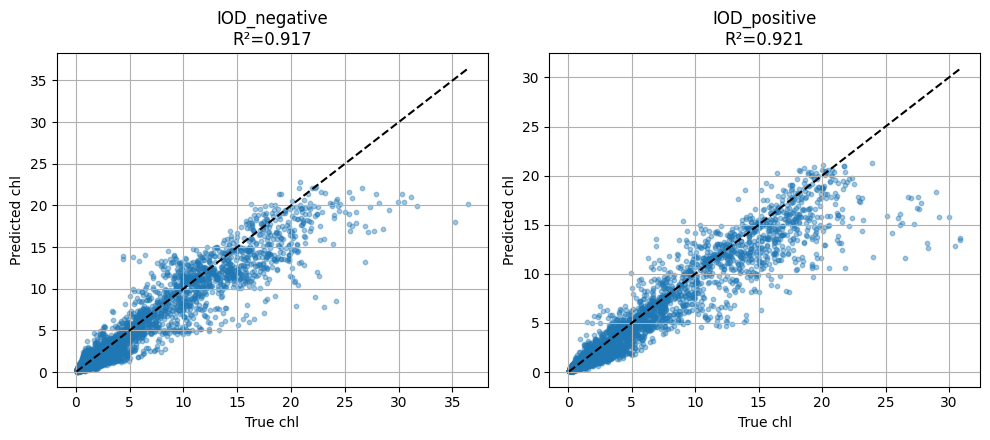

In [5]:
# Default model: XGBoost env+lat_lon+time — scatter on each bucket

DEFAULT_CONFIG = "env+lat_lon+time"
DEFAULT_MODEL = "XGBoost"
default_rec = next(
    (r for r in records if r["config"] == DEFAULT_CONFIG and r["model"] == DEFAULT_MODEL),
    records[0],
)
DEFAULT_CONFIG = default_rec["config"]
DEFAULT_MODEL = default_rec["model"]
print(f"maps/scatter use {DEFAULT_MODEL} / {DEFAULT_CONFIG}")
kind, model, scaler, features = load_artifact(default_rec)

n_b = sum(1 for f in bucket_frames.values() if not f.empty)
fig, axes = plt.subplots(1, max(n_b, 1), figsize=(5 * max(n_b, 1), 4.5), squeeze=False)
ax_i = 0
for bname, frame in bucket_frames.items():
    if frame.empty:
        continue
    y = frame[TARGET].values
    pred = predict(kind, model, scaler, features, frame)
    frame = frame.copy()
    frame["y_pred"] = pred
    bucket_frames[bname] = frame
    ax = axes[0, ax_i]
    ax.scatter(y, pred, alpha=0.4, s=10)
    mn, mx = min(y.min(), pred.min()), max(y.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], "k--")
    ax.set_xlabel(f"True {TARGET}")
    ax.set_ylabel(f"Predicted {TARGET}")
    ax.set_title(f"{bname}\nR²={r2_score(y, pred):.3f}")
    ax.grid(True)
    ax_i += 1
plt.tight_layout()
plt.show()


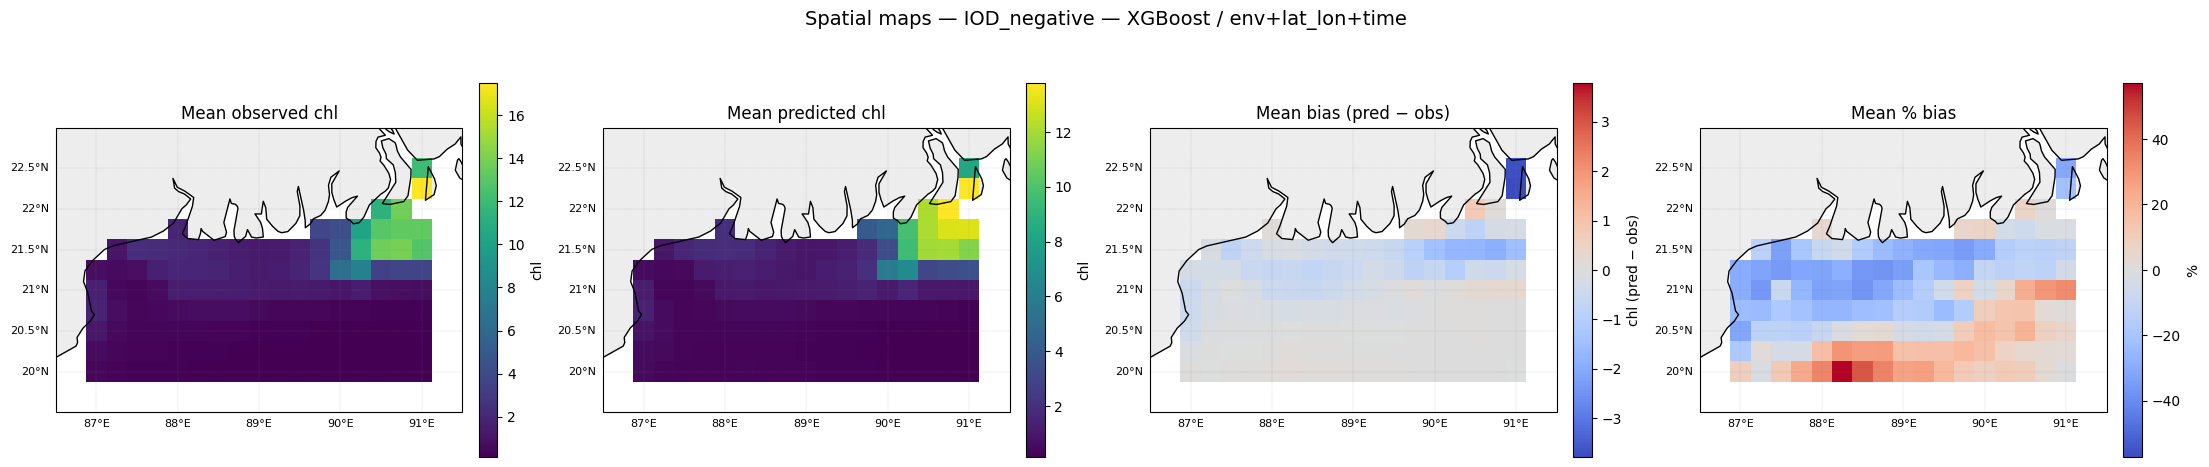

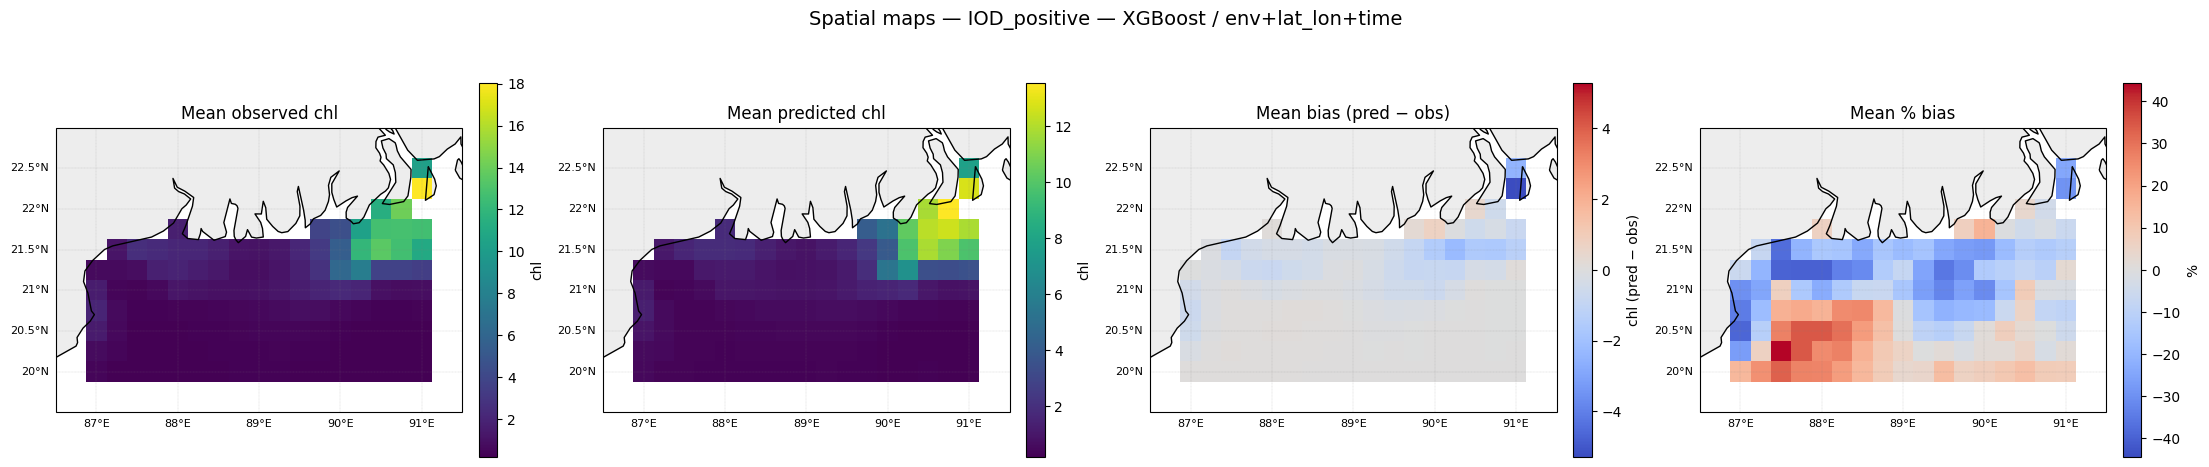

In [6]:
# Cartopy spatial maps for default model on each non-empty bucket

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm


def plot_spatial_maps_cartopy(df_in, title, min_samples=3, obs_cmap="viridis", bias_cmap="coolwarm"):
    if df_in.empty or "y_pred" not in df_in.columns:
        print(f"{title}: no data")
        return

    dfm = df_in.copy()
    dfm["bias"] = dfm["y_pred"] - dfm[TARGET]
    grouped = dfm.groupby(["latitude", "longitude"]).agg(
        obs_mean=(TARGET, "mean"),
        pred_mean=("y_pred", "mean"),
        bias_mean=("bias", "mean"),
        count=(TARGET, "count"),
    ).reset_index()

    lats = np.sort(grouped["latitude"].unique())
    lons = np.sort(grouped["longitude"].unique())
    Lon, Lat = np.meshgrid(lons, lats)
    obs_grid = grouped.pivot(index="latitude", columns="longitude", values="obs_mean").reindex(index=lats, columns=lons).values
    pred_grid = grouped.pivot(index="latitude", columns="longitude", values="pred_mean").reindex(index=lats, columns=lons).values
    bias_grid = grouped.pivot(index="latitude", columns="longitude", values="bias_mean").reindex(index=lats, columns=lons).values
    count_grid = grouped.pivot(index="latitude", columns="longitude", values="count").reindex(index=lats, columns=lons).fillna(0).values

    mask = count_grid < min_samples
    obs_grid_mask = np.ma.masked_where(mask, obs_grid)
    pred_grid_mask = np.ma.masked_where(mask, pred_grid)
    bias_grid_mask = np.ma.masked_where(mask, bias_grid)

    bias_vmax = np.nanmax(np.abs(bias_grid_mask))
    bias_norm = TwoSlopeNorm(vcenter=0.0, vmin=-bias_vmax, vmax=bias_vmax)
    with np.errstate(divide="ignore", invalid="ignore"):
        pct_bias_grid = np.where(obs_grid > 1e-4, 100.0 * (pred_grid - obs_grid) / obs_grid, np.nan)
    pct_mask = mask | ~np.isfinite(pct_bias_grid)
    pct_bias_grid_mask = np.ma.masked_where(pct_mask, pct_bias_grid)
    pct_vmax = np.nanmax(np.abs(np.ma.filled(pct_bias_grid_mask, np.nan)))
    if not np.isfinite(pct_vmax) or pct_vmax == 0:
        pct_vmax = 1.0
    pct_norm = TwoSlopeNorm(vcenter=0.0, vmin=-pct_vmax, vmax=pct_vmax)

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(22, 5), constrained_layout=True)
    extent = [float(lons.min()) - 0.5, float(lons.max()) + 0.5, float(lats.min()) - 0.5, float(lats.max()) + 0.5]

    panels = [
        (obs_grid_mask, obs_cmap, None, f"Mean observed {TARGET}", TARGET),
        (pred_grid_mask, obs_cmap, None, f"Mean predicted {TARGET}", TARGET),
        (bias_grid_mask, bias_cmap, bias_norm, "Mean bias (pred − obs)", f"{TARGET} (pred − obs)"),
        (pct_bias_grid_mask, bias_cmap, pct_norm, "Mean % bias", "%"),
    ]
    for i, (grid, cmap, norm, ttl, clabel) in enumerate(panels, start=1):
        ax = fig.add_subplot(1, 4, i, projection=proj)
        ax.set_extent(extent, crs=proj)
        kw = {"transform": proj, "cmap": cmap, "shading": "auto"}
        if norm is not None:
            kw["norm"] = norm
        pcm = ax.pcolormesh(Lon, Lat, grid, **kw)
        ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
        ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="lightgray", alpha=0.4)
        ax.set_title(ttl)
        fig.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04, label=clabel)
        gl = ax.gridlines(draw_labels=True, linewidth=0.2, color="gray", alpha=0.6, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 8}
        gl.ylabel_style = {"size": 8}

    plt.suptitle(title, fontsize=14)
    plt.show()


for bname, frame in bucket_frames.items():
    plot_spatial_maps_cartopy(frame, title=f"Spatial maps — {bname} — {DEFAULT_MODEL} / {DEFAULT_CONFIG}")
